# Titanic Survival Prediction
## Predicting who survived the Titanic using Machine Learning
**By: Yanna Phani Manjunath Reddy**

In [2]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.to_csv("../data/titanic.csv",index=False)

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")

In [5]:
df=pd.read_csv("../data/titanic.csv")
print(df.head())
print(f"Shape: {df.shape}")

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

## 1. Exploratory Data Analysis

In [8]:
df.info()
print("\n\n")
df.describe()
print("\n\n")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB








PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 2. Visualizations

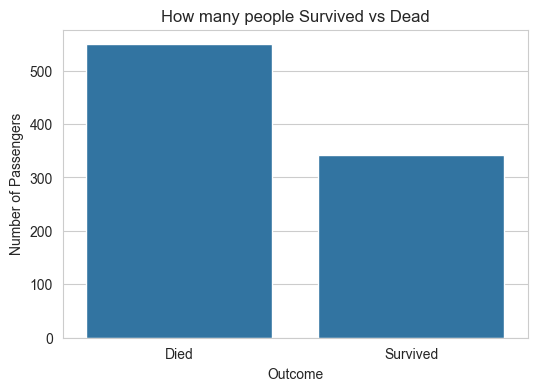

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived",data=df)
plt.title("How many people Survived vs Dead")
plt.xticks([0,1],["Died","Survived"])
plt.xlabel("Outcome")
plt.ylabel("Number of Passengers")
plt.savefig("../images/survival_count.png")
plt.show()

C:\Users\Y.PHANI MANJUNATH\AppData\Local\Temp\ipykernel_14304\4224553840.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.countplot(data=df,x="Sex",hue="Survived",color="green")


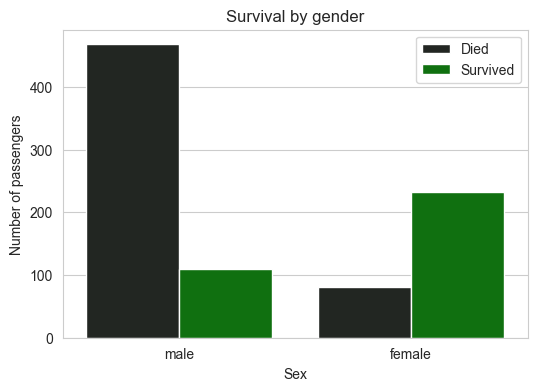

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Sex",hue="Survived",color="green")
plt.title("Survival by gender")
plt.xlabel("Sex")
plt.ylabel("Number of passengers")
plt.legend(["Died","Survived"])
plt.savefig("../images/survival_gender.png")
plt.show()

C:\Users\Y.PHANI MANJUNATH\AppData\Local\Temp\ipykernel_14304\2851529692.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(data=df,x="Pclass",hue="Survived",color="red")


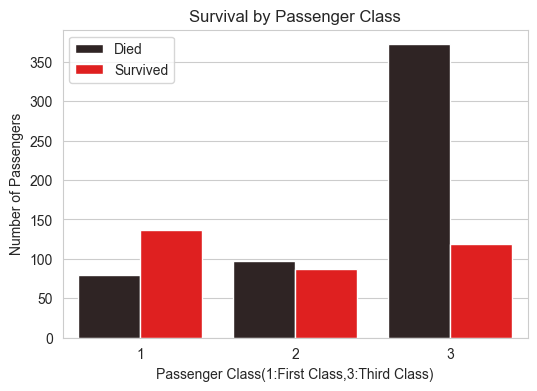

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Pclass",hue="Survived",color="red")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class(1:First Class,3:Third Class)")
plt.ylabel("Number of Passengers")
plt.legend(["Died","Survived"])
plt.savefig("../images/Survival_pclass.png")

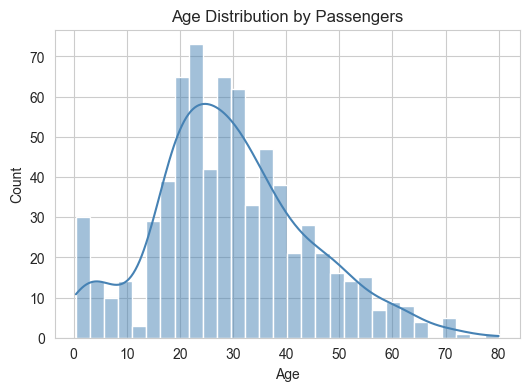

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"].dropna(),bins=30,kde=True,color='steelblue')
plt.title("Age Distribution by Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../images/age_distribution.png")
plt.show()

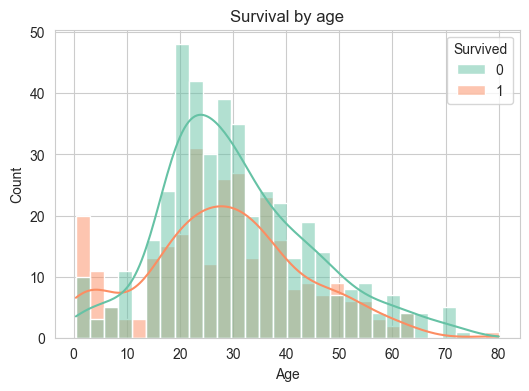

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x="Age",hue="Survived",bins=30,kde=True,palette="Set2")
plt.title("Survival by age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../images/age_survival.png")
plt.show()

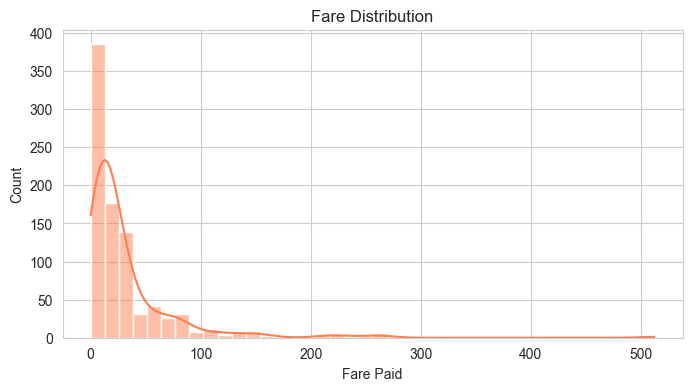

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df["Fare"], 
             bins=40, 
             kde=True, 
             color="coral")
plt.title("Fare Distribution")
plt.xlabel("Fare Paid")
plt.ylabel("Count")
plt.savefig("../images/fare_distribution.png")
plt.show()

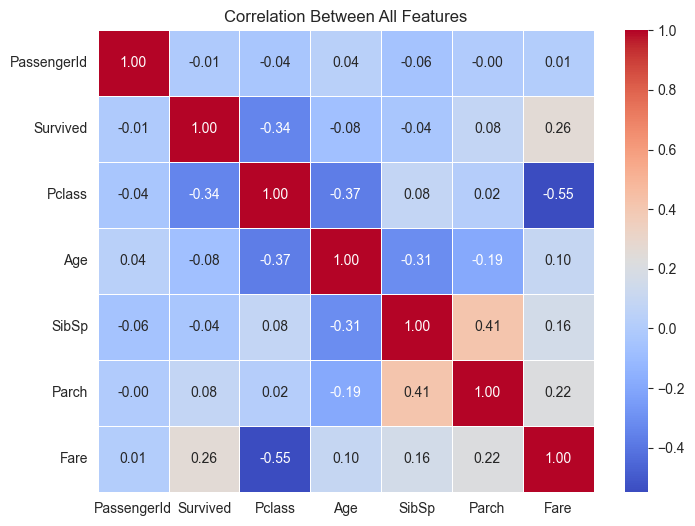

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)      # adds thin lines between cells
plt.title("Correlation Between All Features")
plt.savefig("../images/heatmap.png")
plt.show()

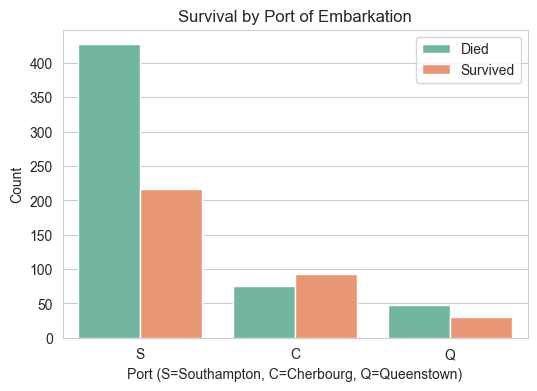

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked", 
              hue="Survived", 
              data=df, 
              palette="Set2")
plt.title("Survival by Port of Embarkation")
plt.xlabel("Port (S=Southampton, C=Cherbourg, Q=Queenstown)")
plt.ylabel("Count")
plt.legend(["Died","Survived"])
plt.savefig("../images/survival_embarked.png")
plt.show()

## 3. Data Cleaning

In [26]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [28]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"],inplace=True)

In [29]:
df["Age"].fillna(df["Age"].median(),inplace=True)

C:\Users\Y.PHANI MANJUNATH\AppData\Local\Temp\ipykernel_14304\860536840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [32]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

In [34]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})

In [35]:
df["Embarked"]=df["Embarked"].map({"S":0,"C":1,"Q":2})

In [36]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [37]:
df.shape

(891, 8)

## 4. Model Building

In [39]:
X=df.drop(columns=["Survived"])

In [40]:
y=df["Survived"]

In [43]:
print(X.shape,y.shape,list(X.columns),sep=" | ")


(891, 7) | (891,) | ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [44]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [50]:
print(X_train.shape,y_train.shape,sep=" | ")

(712, 7) | (712,)


In [51]:
model=RandomForestClassifier(n_estimators=100,random_state=42)

In [52]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [53]:
y_pred = model.predict(X_test)

In [55]:
accuracy=accuracy_score(y_test,y_pred)

In [56]:
print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, 
                            target_names=["Died","Survived"]))

Model Accuracy: 82.68%

Detailed Report:
              precision    recall  f1-score   support

        Died       0.84      0.88      0.86       105
    Survived       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



C:\Users\Y.PHANI MANJUNATH\AppData\Local\Temp\ipykernel_14304\3782947208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance",y="Features",data=feature_importance,palette="viridis")


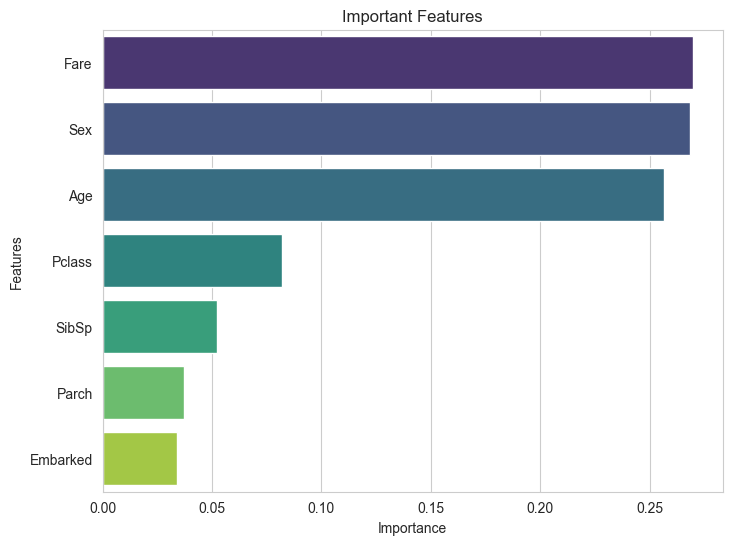

In [57]:
feature_importance=pd.DataFrame({
    "Features":X.columns,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x="Importance",y="Features",data=feature_importance,palette="viridis")
plt.title("Important Features")
plt.savefig("../images/feature_importance.png")
plt.show()

In [58]:
print(feature_importance)

   Features  Importance
5      Fare    0.269744
1       Sex    0.268418
2       Age    0.256426
0    Pclass    0.081891
3     SibSp    0.052077
4     Parch    0.037390
6  Embarked    0.034054


## 5. Conclusion

In [61]:
print("""
=== TITANIC SURVIVAL PREDICTION — KEY FINDINGS ===

Dataset    : 891 passengers, 8 features
Model      : Random Forest (100 trees)
Accuracy   : 82.68%

TOP SURVIVAL FACTORS:
1. Fare paid      → wealthier passengers survived more
2. Gender         → females had much higher survival rate
3. Age            → children were prioritized
4. Passenger class→ 1st class had best survival chances

CONCLUSION:
Survival on the Titanic was heavily influenced by
socioeconomic status and gender.
Wealthy women in 1st class had the highest chance of survival.
Poor young men in 3rd class had the lowest chance.
""")



=== TITANIC SURVIVAL PREDICTION — KEY FINDINGS ===

Dataset    : 891 passengers, 8 features
Model      : Random Forest (100 trees)
Accuracy   : 82.68%

TOP SURVIVAL FACTORS:
1. Fare paid      → wealthier passengers survived more
2. Gender         → females had much higher survival rate
3. Age            → children were prioritized
4. Passenger class→ 1st class had best survival chances

CONCLUSION:
Survival on the Titanic was heavily influenced by
socioeconomic status and gender.
Wealthy women in 1st class had the highest chance of survival.
Poor young men in 3rd class had the lowest chance.

